In [1]:
# TODO Currently accesses .pos files from local directory. Must change to download from Zenodo when available

# Zachary Katz
# zachary_katz@mines.edu

"""
Make and save the catalog of Whillans Stick Slip Events from .pos files, 
available from XXX at DOI. Keep the .pos files in the same folder
structure they were downloaded as, and set the top level directory as the
variable dir below. Make 

v1.0 01 November 2024
    Clean catalog creation using Catalog.py
    Outputs Events, EventStartTimes, and NoData folders
v2.0 08 March 2024
    Paper Version
"""


# Imports
import os
import logging
from concurrent.futures import ThreadPoolExecutor
import sys

sys.path.append("..")

import src.Catalog.Catalog as Catalog

%reload_ext autoreload
%autoreload 2

################################################################################
########################## User Defined Variables ##############################
# fmt: off

# Stations, Years, Data Path
dir = "/mnt/e/Zenodo/PPP"
stas = ["la01", "la02", "la03", "la04", "la05", "la06", "la07", "la08", "la09",
        "la10", "la11", "la12", "la13", "la14", "la15", "la16", "la17", "la18",
        "ws04", "ws05",
        "gz01", "gz02", "gz03", "gz04", "gz05", "gz06", "gz07", "gz08", "gz09",
        "gz10", "gz11", "gz12", "gz13", "gz14", "gz15", "gz16", "gz17", "gz18",
        "gz19", "gz20",
        "mg01", "mg02", "mg03", "mg04", "mg05", "mg06", "mg07",
        "slw1"
        ]
year_arr = [['2018']]
# Detection parameters
max_gap_len = 120 # Maximum gap length to interpolate [seconds]
window = 150 # Window size for least-squares averaging [minutes]
slide = 5 # Slide size for least-squares averaging [minutes]
cull_time = 30 # Remove catalog events lasting less than this time [minutes]
cull_dist = 0.1 # Remove catalog events with less than this distance [meters]
plot_bool = False # Flag to plot catalog
min_stas = 2 # Minimum number of active stations needed for an event
hr_off = 0 # Offset for hours on either side of threshold to save [hours]d

# Log Level
# Currently implemented: ERROR, WARNING, INFO, DEBUG
# Each level also includes all levels above it.
loglevel = "INFO" 

# fmt: on
########################## User Defined Variables ##############################
################################################################################


# Helper functions
def set_log_level(loglevel: str) -> None:
    """Set logging level for the run

    Parameters
    ----------
    loglevel : str
        Logging level
    """
    FORMAT = "%(asctime)s %(name)s %(levelname)s: %(message)s"
    DATEFMT = "%Y-%m-%d %H:%M:%S"
    if loglevel == "ERROR":
        logging.basicConfig(
            format=FORMAT, datefmt=DATEFMT, level=logging.ERROR, force=True
        )
    elif loglevel == "WARNING":
        logging.basicConfig(
            format=FORMAT, datefmt=DATEFMT, level=logging.WARNING, force=True
        )
    elif loglevel == "INFO":
        logging.basicConfig(
            format=FORMAT, datefmt=DATEFMT, level=logging.INFO, force=True
        )
    elif loglevel == "DEBUG":
        logging.basicConfig(
            format=FORMAT, datefmt=DATEFMT, level=logging.DEBUG, force=True
        )


# Load station function
def load_station(sta: str, years: list, max_gap_len: int) -> Catalog.Datastream:
    interpolation_time, run = Catalog.set_interpolation_time(sta, years)
    if run:
        logger.info(f"Creating Dataframe for {sta}")
        cat = Catalog.Datastream(os.path.join(dir, sta), sta, years, interpolation_time)
        logger.info(f"Interpolating {sta}")
        if not cat.data.empty:
            cat.findgaps(max_gap_len)
            return cat
        else:
            return None

In [3]:
# Make Catalog

# Setup logger
set_log_level(loglevel)
logger = logging.getLogger(__name__)

# Convert window and slide to 15 second chunks
window = window * 60 / 15
slide = slide * 60 / 15

# Create Catalog
# Not fully parallelized due to memory constraints
for years in year_arr:
    with ThreadPoolExecutor() as executor:
        results = executor.map(
            load_station, stas, [years] * len(stas), [max_gap_len] * len(stas)
        )
    cats = [cat for cat in results if cat is not None]

2025-06-07 11:50:30 __main__ INFO: Creating Dataframe for la01
2025-06-07 11:50:30 __main__ INFO: Creating Dataframe for la02
2025-06-07 11:50:30 __main__ INFO: Creating Dataframe for la03


2025-06-07 11:50:30 __main__ INFO: Creating Dataframe for la04
2025-06-07 11:50:30 __main__ INFO: Creating Dataframe for la05
2025-06-07 11:50:30 __main__ INFO: Creating Dataframe for la06
2025-06-07 11:50:30 __main__ INFO: Creating Dataframe for la07
2025-06-07 11:50:30 __main__ INFO: Creating Dataframe for la08
2025-06-07 11:50:30 __main__ INFO: Creating Dataframe for la09
2025-06-07 11:50:30 __main__ INFO: Creating Dataframe for la10
2025-06-07 11:50:30 __main__ INFO: Creating Dataframe for la11
2025-06-07 11:50:30 __main__ INFO: Creating Dataframe for la12
2025-06-07 11:50:30 __main__ INFO: Creating Dataframe for la13
2025-06-07 11:50:30 __main__ INFO: Creating Dataframe for la14
2025-06-07 11:50:30 __main__ INFO: Creating Dataframe for la15
2025-06-07 11:50:30 __main__ INFO: Creating Dataframe for la16
2025-06-07 11:50:30 __main__ INFO: Creating Dataframe for la17
2025-06-07 11:50:30 __main__ INFO: Creating Dataframe for la18
2025-06-07 11:50:30 __main__ INFO: Creating Dataframe f

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/e/Zenodo/PPP/la01'

1208102   -275356.108904
1208103   -275356.112695
1208104   -275356.106256
1208105   -275356.102143
1208106   -275356.106860
               ...      
1217844   -275354.320138
1217845   -275354.330089
1217846   -275354.331232
1217847   -275354.326522
1217848   -275354.330527
Name: x, Length: 9747, dtype: float64
Series([], Name: x, dtype: float64)
Series([], Name: x, dtype: float64)
Series([], Name: x, dtype: float64)
1055541   -295499.703386
1055542   -295499.706519
1055543   -295499.704367
1055544   -295499.696662
1055545   -295499.701170
               ...      
1062124   -295498.289456
1062125   -295498.288297
1062126   -295498.282241
1062127   -295498.295818
1062128   -295498.283775
Name: x, Length: 6588, dtype: float64
Series([], Name: x, dtype: float64)
966004   -154967.316396
966005   -154967.323200
966006   -154967.319873
966007   -154967.321895
966008   -154967.318392
              ...      
967524   -154966.592287
967525   -154966.593611
967526   -154966.588711
967527   -1549

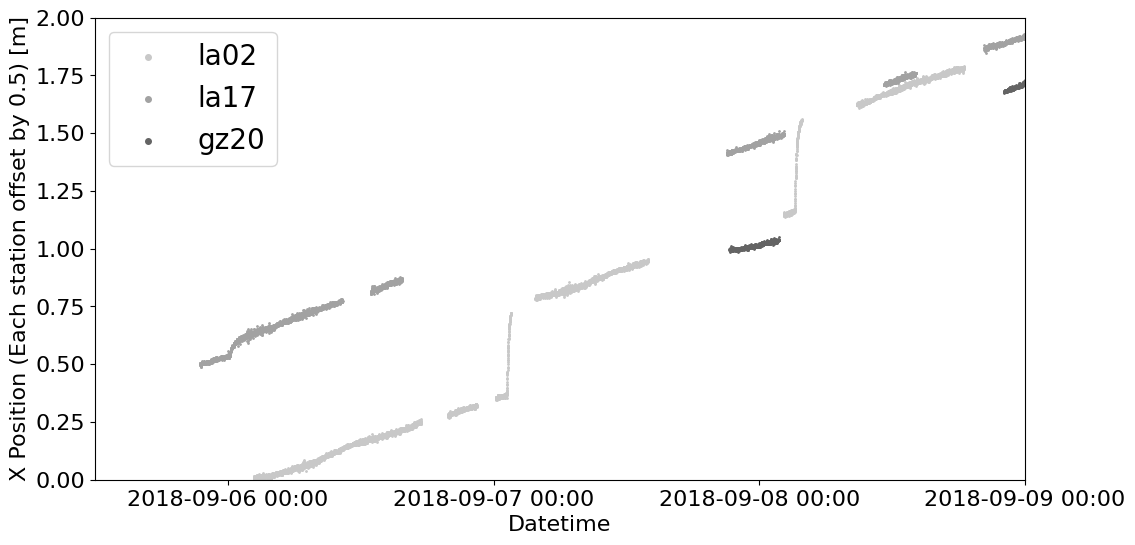

In [106]:
# Plot full GNSS data 2018
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

st = pd.to_datetime("2018-09-05T12:00:00")
et = pd.to_datetime("2018-09-09")

fig, ax = plt.subplots(figsize=(12, 6))
i = 0
colors = ["#c8c8c8", "#a2a2a2", "#646464", "#000000"]
for cat in cats[:]:
    cat_data = cat.data[(cat.data["time"] >= st) & (cat.data["time"] <= et)]
    label = cat.sta.split("/")[-1]
    # print(cat_data, cat.sta)
    # print(idx.values)
    # if len(idx.values) == 1:
    #    print(cat_data['x'] )
    #    print(cat_data['x'].loc[idx[0]] )
    #    demeaned = cat_data['x'] - cat_data['x'].loc[idx[0]] + 0.5 * i
    print(cat_data["x"])
    if not cat_data["x"].empty:
        demeaned = cat_data["x"] - cat_data["x"].iloc[0] + 0.5 * i
        ax.scatter(
            pd.to_datetime(cat_data["time"]),
            demeaned,
            label=label,
            color=colors[i],
            s=1,
        )
        i += 1

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))

ax.set_xlim(st, et)
ax.set_ylim(0, 2)
ax.set_xlabel("Datetime", fontsize=16)
ax.set_ylabel("X Position (Each station offset by 0.5) [m]", fontsize=16)
ax.tick_params(axis="both", which="major", labelsize=16)
# Halve the x axis labels
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.legend(loc="upper left", fontsize=20, markerscale=4)
# Legend dot size increase

[1300480]
1300480   -276212.630259
1300481   -276212.627036
1300482   -276212.636337
1300483   -276212.639246
1300484   -276212.633633
               ...      
1318490   -276209.653982
1318491   -276209.663893
1318492   -276209.659686
1318493   -276209.654197
1318494   -276209.633065
Name: x, Length: 18015, dtype: float64
-276212.6302592313
[712939]
712939   -252850.518676
712940   -252850.516150
712941   -252850.523341
712942   -252850.523803
712943   -252850.521700
              ...      
726726   -252848.246383
726727   -252848.250899
726728   -252848.250879
726729   -252848.252180
726730   -252848.244614
Name: x, Length: 13792, dtype: float64
-252850.51867567695
[743819]
743819   -263988.581066
743820   -263988.567473
743821   -263988.581665
743822   -263988.588435
743823   -263988.581469
              ...      
756136   -263986.240010
756137   -263986.237917
756138   -263986.246889
756139   -263986.238178
756140   -263986.246736
Name: x, Length: 12322, dtype: float64
-263988.58106

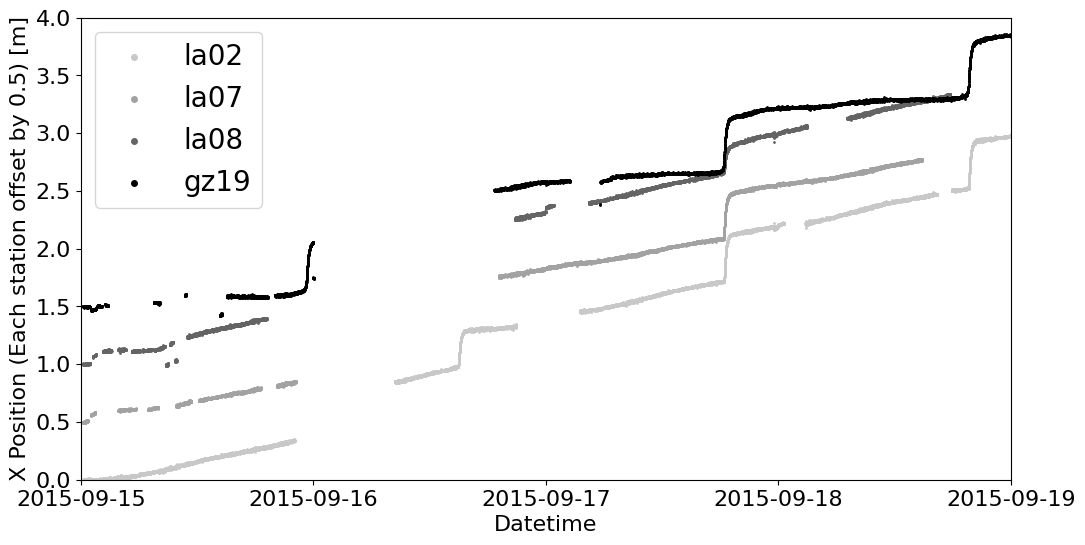

In [ ]:
# Plot full GNSS data 2015
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

st = pd.to_datetime("2015-09-15T00:16:00")
et = pd.to_datetime("2015-09-19")

fig, ax = plt.subplots(figsize=(12, 6))
i = 0
colors = ["#c8c8c8", "#a2a2a2", "#646464", "#000000"]
for cat in cats[:]:
    cat_data = cat.data[(cat.data["time"] >= st) & (cat.data["time"] <= et)]
    label = cat.sta.split("/")[-1]
    idx = cat_data[cat_data["time"] == st].index
    print(idx.values)
    if len(idx.values) == 1:
        print(cat_data["x"])
        print(cat_data["x"].loc[idx[0]])
        demeaned = cat_data["x"] - cat_data["x"].loc[idx[0]] + 0.5 * i

        ax.scatter(
            pd.to_datetime(cat_data["time"]),
            demeaned,
            label=label,
            color=colors[i],
            s=1,
        )
        i += 1
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

st = pd.to_datetime("2015-09-15")
ax.set_xlim(st, et)
ax.set_ylim(0, 4)
ax.set_xlabel("Datetime", fontsize=16)
ax.set_ylabel("X Position (Each station offset by 0.5) [m]", fontsize=16)
ax.tick_params(axis="both", which="major", labelsize=16)
# Halve the x axis labels
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.legend(loc="upper left", fontsize=20, markerscale=4)
# Legend dot size increase